<a href="https://colab.research.google.com/github/csorty/car/blob/main/tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[['Order', 'Yr Sold'], ['Year Built', 'Garage Yr Blt'], ['Total Bsmt SF', '1st Flr SF'], ['Gr Liv Area', 'TotRms AbvGrd'], ['Garage Cars', 'Garage Area']]
      Order        PID  MS SubClass  Lot Frontage  Lot Area  Overall Qual  \
0         1  526301100           20         141.0     31770             6   
1         2  526350040           20          80.0     11622             5   
2         3  526351010           20          81.0     14267             6   
3         4  526353030           20          93.0     11160             7   
4         5  527105010           60          74.0     13830             5   
...     ...        ...          ...           ...       ...           ...   
2925   2926  923275080           80          37.0      7937             6   
2926   2927  923276100           20           NaN      8885             5   
2927   2928  923400125           85          62.0     10441             5   
2928   2929  924100070           20          77.0     10010             5  

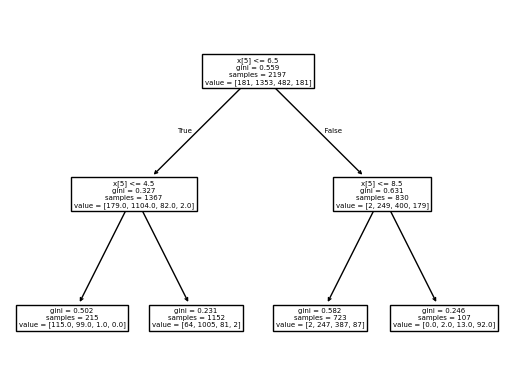

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import tree
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("/content/AmesHousing.csv")
data = data.select_dtypes(include='number')
corr_matrix = data.corr()
corr_r = []
for i in range(len(data.columns)):
  for j in range(i+1, len(data.columns)):
    if abs(corr_matrix.iloc[i, j]) > 0.8:
      #data = data.drop(columns = [data.columns[i]])
      corr_r.append([data.columns[i], data.columns[j]])
data = data.drop(columns = np.array(corr_r)[:,1])
print(corr_r)
print(data)

X = data.drop(columns=["SalePrice"])
y = data["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y)
tr33 = tree.DecisionTreeRegressor()
tr33.fit(X_train, y_train)
score = tr33.score(X_test, y_test)
print(score)

#А до 100000, В от 100000 до 200000, С от 200000 до 300000, Д от 300000
'''data["SalePrice"].hist(bins=100)
plt.show()'''

y_cat = []
for elem in y:
  if elem < 100000:
    y_cat.append("A")
  elif elem < 200000:
    y_cat.append("B")
  elif elem < 300000:
    y_cat.append("C")
  else:
    y_cat.append("D")

X_train, X_test, y_train, y_test = train_test_split(X, y_cat)
tr33 = tree.DecisionTreeClassifier(max_depth=2)
tr33.fit(X_train, y_train)
score = tr33.score(X_test, y_test)
print(score)

tree.plot_tree(tr33)
plt.show()